# CM3060 Natural Language Processing

I implemented a statistical model as a baseline and an embedding-based model for comparison.
1) A statistical model (TF-IDF + Multinomial Naive Bayes)
2) An embedding-based model (GloVe + Logistic Regression)

Both models use the same evaluation methods. Both are train/test split using accuracy, precision, recall, F1-score and confusion matrix.

In [1]:
# Importing and loading dataset

import pandas as pd

# loading dataset from local saved CSV downloaded from Kaggle
df = pd.read_csv("IMDB Dataset.csv")

# simple test to check if loading data correctly
print("Rows, columns:", df.shape)
## output Rows, columns (50000, 2) indicates successful loading
print(df.head(3))
print(df["sentiment"].value_counts())

Rows, columns: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [2]:
# Label encoding
# convert string labels into binary : 
# positive = 1 , negative = 0

df["label"]  = df["sentiment"].map({"positive": 1, "negative": 0})

# print test to check if mapping is correct
print(df[["sentiment", "label"]].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


In [3]:
## Train/test split + text preprocessing
from sklearn.model_selection import train_test_split

# text and label
x = df["review"]
y = df["label"]

# split into train/test using stratification to preserve class balance
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   test_size = 0.2,
                                                   random_state = 42,
                                                   stratify = y)

# preprocessing step (lower case all text)
x_train = x_train.str.lower()
x_test = x_test.str.lower()

print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
                                                   

Training samples: 40000
Test samples: 10000


# Model A : Statistical Model
(TF-IDF + Multinomial Naive Bayes)
This will be the baseline to compare embedding-based models

In [4]:
# Statistical model (baseline)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# pipeline = vectoriser + model in one clean block
## data preperation for statistical
## text -> tokenised -> TF-IDF matrix 0> Naive Bayes classifier
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words = "english", # pre-processing, remove common words that usually add noise
        max_features = 20000 # cap vocabulary for efficiency + consistency
    )),
    ("nb", MultinomialNB())
])

## TF-IDF (frequency-based bag-of-words style representation)^
## created a sparse frequency-weighted matrix (word features)

# train baseline model
baseline_model.fit(x_train, y_train)

# predict based on test set
y_pred = baseline_model.predict(x_test)

#evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report: \n", classification_report(y_test, y_pred, digits = 4))
print("\nConfusion matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8616

Classification report: 
               precision    recall  f1-score   support

           0     0.8580    0.8666    0.8623      5000
           1     0.8653    0.8566    0.8609      5000

    accuracy                         0.8616     10000
   macro avg     0.8616    0.8616    0.8616     10000
weighted avg     0.8616    0.8616    0.8616     10000


Confusion matrix: 
 [[4333  667]
 [ 717 4283]]


# Model B : Embedding-Based Model
(GloVe + Logistic Regression)
This model represents text using dense semantic vectors (pre-trained GloVe embeddings - glove6b)
Each review is represented by the average of its word vectors and classified using Logistic Regression

In [5]:
## Embedding model
import numpy as np

def load_glove_embeddings(filepath):
#    loads pretrained GloVe embeddings from a txt file
#    Returns :
#        dict: {word -> np.array(vector)}
    embeddings = {}
    with open(filepath, encoding = "utf8") as f :
        for line in f:
            values = line.split()
            word = values [0]
            vector = np.asarray(values[1:], dtype = "float32")
            embeddings[word] = vector
        return embeddings # return after reading file

glove_path = "glove.6B.100d.txt" 
embeddings = load_glove_embeddings(glove_path)

print ("Number of words loaded:", len(embeddings))

Number of words loaded: 400000


In [6]:
import re

# tokenise text into words to ensure consistency
# convert text to lowercase and removes all special characters
def simple_tokenize(text):
    text = re.sub(r"[^a-z0-9\s]", " ", text.lower())
    return text.split()

In [7]:
## Data preperation
## text -> split into words -> map each word to a vector -> avg

# converts one review (string) into a fixed-length vector by averaging the embedding of all known words in the review
# if no words are found in the embedding vocab, returns a zero vector
def review_to_vector(review, embeddings, dim=100):
    words = simple_tokenize(review)
    vectors = [embeddings[word] for word in words if word in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# create dense vector matrices for train/test
x_train_vec = np.vstack([review_to_vector(r, embeddings) for r in x_train])
x_test_vec = np.vstack([review_to_vector(r, embeddings) for r in x_test])

##Word embeddings (GloVe) + averaging into a single vector per review ^
##This produces dense vectors (e.g., 100 dimensions per review).


print(x_train_vec.shape)
print(x_test_vec.shape)

(40000, 100)
(10000, 100)


In [8]:
## Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

embedding_model = LogisticRegression(max_iter=1000)

# train on dense vectors
embedding_model.fit(x_train_vec, y_train)

# predict on test vectors
y_pred_emb = embedding_model.predict(x_test_vec)

# evaluate embedding model
print("Accuracy:", accuracy_score(y_test, y_pred_emb))
print("\nClassification report: \n", classification_report(y_test, y_pred_emb, digits=4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_emb))

Accuracy: 0.7998

Classification report: 
               precision    recall  f1-score   support

           0     0.7957    0.8068    0.8012      5000
           1     0.8041    0.7928    0.7984      5000

    accuracy                         0.7998     10000
   macro avg     0.7999    0.7998    0.7998     10000
weighted avg     0.7999    0.7998    0.7998     10000


Confusion matrix:
 [[4034  966]
 [1036 3964]]


# Summary (comparison)
Statistical Model - Accuracy = 0.8614
Embedding-based Model - Accuracy = 0.7854
Both models were evaluated on the same test split and using the same metrics, hence a fair comparison

In [9]:
# Deep learning model (Keras) , preprocessing
# convert each review into a fixed-length sequence of integers for neural network to process
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000   # keep similar to TF-IDF for fair comparison
MAX_LEN = 200        # longer reviews are truncated

# tokenizer builds vocab from training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

# converts text
train_seq = tokenizer.texts_to_sequences(x_train)
test_seq  = tokenizer.texts_to_sequences(x_test)

# ensures fixed length
X_train_dl = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_dl  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print("DL train shape:", X_train_dl.shape)
print("DL test shape:", X_test_dl.shape)

C:\Users\me\tf311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


DL train shape: (40000, 200)
DL test shape: (10000, 200)


In [10]:
# Deep learning model (Keras) , architecture
# 1. Embedding : maps each word ID -> dense vector 
# 2. GlobalAveragePooling : average word vectors -> single review vector
# 3. Dense(sigmoid) : outputs probability of positive sentiment
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam

# dense representation
EMBED_DIM = 64  # size of learned word vectors

dl_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    GlobalAveragePooling1D(),
    Dense(1, activation="sigmoid")
])

# training configuration
# binary_crossentropy : standard loss for binary classification
# Adam: commonly used optimizer for neural networks
dl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#dl_model.summary()

In [11]:
# Deep learning model (Keras) , training
# evaluation/training : train on labelled data, validate to monitor generalisation
# use a validation split from the training data to watch for overfitting.

EPOCHS = 5
BATCH_SIZE = 128

history = dl_model.fit(
    X_train_dl, y_train,
    validation_split=0.2,   # 20% of training data used for validation
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7156 - loss: 0.6274 - val_accuracy: 0.7908 - val_loss: 0.5373
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8194 - loss: 0.4645 - val_accuracy: 0.8340 - val_loss: 0.4156
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8559 - loss: 0.3710 - val_accuracy: 0.8584 - val_loss: 0.3603
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8768 - loss: 0.3198 - val_accuracy: 0.8687 - val_loss: 0.3314
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8901 - loss: 0.2863 - val_accuracy: 0.8736 - val_loss: 0.3139


In [12]:
# Deep learning model (Keras) , evaluation
# keep evaluation identical to the baseline so the comparison is fair.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# model outputs probabilities
# convert to 0/1 labels using threshold 0.5
y_prob_dl = dl_model.predict(X_test_dl, verbose=0).ravel()
y_pred_dl = (y_prob_dl >= 0.5).astype(int)

print("Deep Learning Accuracy:", accuracy_score(y_test, y_pred_dl))
print("\nDeep Learning Classification report:\n",
      classification_report(y_test, y_pred_dl, digits=4))
print("\nDeep Learning Confusion matrix:\n",
      confusion_matrix(y_test, y_pred_dl))

Deep Learning Accuracy: 0.8726

Deep Learning Classification report:
               precision    recall  f1-score   support

           0     0.8659    0.8818    0.8738      5000
           1     0.8796    0.8634    0.8714      5000

    accuracy                         0.8726     10000
   macro avg     0.8727    0.8726    0.8726     10000
weighted avg     0.8727    0.8726    0.8726     10000


Deep Learning Confusion matrix:
 [[4409  591]
 [ 683 4317]]


In [13]:
# comparison between baseline and deep learning 
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame([
    {"Model": "TF-IDF + MultinomialNB (Baseline)", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "Keras Embedding + AvgPool + Dense", "Accuracy": accuracy_score(y_test, y_pred_dl)},
])

comparison

,Model,Accuracy
0,TF-IDF + MultinomialNB (Baseline),0.8616
1,Keras Embedding + AvgPool + Dense,0.8726


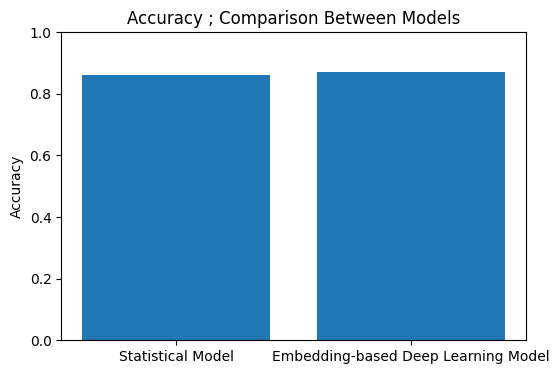

In [17]:
import matplotlib.pyplot as plt

# comparing statistical and embedding-based models
models = ["Statistical Model", "Embedding-based Deep Learning Model"]
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dl)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy ; Comparison Between Models")
plt.show()

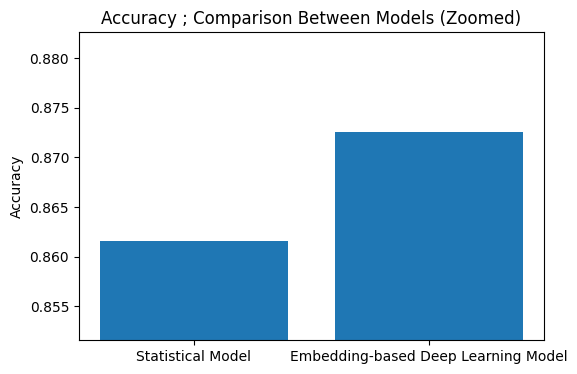

In [18]:
# values were too close together, a second zoomed in model to see the comparison
from sklearn.metrics import accuracy_score

models = ["Statistical Model", "Embedding-based Deep Learning Model"]
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dl)
]

# Compute bounds dynamically
y_min = min(accuracies) - 0.01
y_max = max(accuracies) + 0.01

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.ylim(y_min, y_max)
plt.title("Accuracy ; Comparison Between Models (Zoomed)")
plt.show()